In [1]:
%run shared_imports.py

from datetime import date
from datetime import timedelta

In [2]:
engine = make_engine("settings.toml")
session = Session(engine)

local_engine = make_engine("settings_local.toml")
local_session = Session(local_engine)

# Analyzing Production Ruin Frequency vs Simulation

The data we're getting from prod and the data we're getting from test are slightly different in an important way: the prod data was produced in real-time over the course of a month, and the test rounds were all rapid-fire, one after another, over the course of a day, with each round taking about 38 seconds to spin up, generate ruins, write the ruin data to disk, and restart.

This is after several balance features in, so we choose a month-long range that matches the features/reworks/loot changes we care about:

| Feature               | Date       |
| --------------------- | ---------- |
| Deepstorage Rework    | 2024-07-30 |
| Explorer Rework       | 2024-05-27 |
| DVORAK Ruin           | 2024-07-25 |
| Tarot Cards           | 2024-04-24 |
| Mech Transport Rework | 2024-03-21 |
| Rocky Motel           | 2024-06-12 |
| Casino                | 2024-06-29 |
| Abandoned Sec Shuttle | 2024-08-04 |
 | |

In [3]:
query = session.query(Feedback.datetime, Feedback.json).join(Round).filter(
        Feedback.key_name == 'ruin_placement',
        Round.start_datetime >= datetime(2024, 8, 24),
        Round.start_datetime < datetime(2024, 9, 24))

raw_prod_ruins = pd.read_sql_query(query.statement, session.connection())

The test rounds started at ID 3600, so we grab as many as there were real rounds.

In [4]:
query = local_session.query(Feedback.json).join(Round).filter(
    Feedback.key_name == 'ruin_placement',
    Round.id > 4045).limit(len(raw_prod_ruins))

raw_test_ruins = pd.read_sql_query(query.statement, local_session.connection())

## Selecting Ruins

Create the list of ruins we're looking at. Can be a lot or a little.

In [5]:
problem_ruins = [
    "abandoned_sec_shuttle.dmm",
    "abandonedzoo.dmm",
    "blowntcommsat.dmm",
    "casino.dmm",
    "deepstorage.dmm",
    "derelict3.dmm", # space dragon
    "derelict5.dmm",
    "dj.dmm",
    "intactemptyship.dmm",
    "listeningpost.dmm",
    "meatpackers.dmm",
    "mechtransport.dmm",
    "onehalf.dmm",
    "rocky_motel.dmm",
    "syndicatedruglab.dmm",
    "syndiecakesfactory.dmm",
    "telecomns_returns.dmm",
    "turretedoutpost.dmm",
    "ussp_tele.dmm",
    "ussp.dmm",
    "wizardcrash.dmm",
    "wreckedcargoship.dmm",
]
ruin_shortnames = [x.replace('.dmm', '') for x in problem_ruins]

## Processing Feedback JSON

These functions are applied to dataframes with feedback JSON data to either get the sum total of ruins spawned during a round, or the discrete count of each ruin we care about. After we apply these functions we typically drop the JSON column so it doesn't make the remaining work challenging.

In [6]:
def apply_total_ruin_count(text):
    keys, values = zip(*[("total", sum(1 for ruin in text['data'].values() if ruin["map"] in problem_ruins))])
    return pd.Series(values, index=keys)

def get_total_ruin_count(df):
    return pd.concat([df, df['json'].apply(apply_total_ruin_count)], axis=1).drop(['json'], axis=1)
    
def apply_individual_ruin_counts(text):
    keys, values = zip(*[(p.replace('.dmm', ''), sum(1 for ruin in text['data'].values() if ruin["map"] == p)) for p in problem_ruins])
    return pd.Series(values, index=keys)

def get_individual_ruin_counts(df):
    return pd.concat([df, df['json'].apply(apply_individual_ruin_counts)], axis=1).drop(['json'], axis=1)

In [7]:
test_total_ruin_count = get_total_ruin_count(raw_test_ruins)
prod_dated_ruin_count = get_total_ruin_count(raw_prod_ruins)
prod_dated_ruin_count['datetime'] = pd.to_datetime(prod_dated_ruin_count['datetime']).dt.date

## Normalizing Data

Now we're going to try and make the tables consistent in data. This means we need to remove time values from the prod counts, only leaving the dates, and add dates to the test counts.

Comparing results in terms of "days" isn't a necessarily meaningful measurement but it's useful for an approximation of what the overall results might look like, without having to dive into the precision of per-round statistics (although we do that later when generating our histograms).

So we find out how many rounds were run each day of the month and create a cumulative array of them in order to bucket the test runs into those ranges. We also create a dataframe keying those buckets to their respective dates. In other words, if there were 11 rounds on the first day in real life, then the range for the first simulated day will be (0, 11].

In [8]:
def create_summed_dates(df):
    firstday = datetime.fromisoformat("2024-08-05")
    rounds_per_day = df.resample('1d', on='datetime').apply({'json': 'count'})['json'].to_list()
    cumulative_rounds = np.cumsum([0] + rounds_per_day)
    return pd.DataFrame({
        'val': [x for i, x in enumerate(cumulative_rounds)],
        'dt': [firstday + timedelta(days=i) for i, x in enumerate(cumulative_rounds)],
    })

summed_dates = create_summed_dates(raw_prod_ruins)

This probably incredibly inefficient but I couldn't figure out a better way to do it, despite many attempts. As above, we wish to bucket every row in the test data into an interval that acts as its simulated date. Then we want to get the real dates by looking them up in the summed data, and then returning the date when the index of the summed data row is within the range in our round data.

In [9]:
def assign_date_by_range(row):
    for r in summed_dates.iterrows():
        val = r[1].val
        dt = r[1]["dt"]
        if val >= row.range.left and val <= row.range.right:
            return dt

def from_range_to_date(df):
    return pd.concat([df.apply(assign_date_by_range, axis=1).rename('datetime'), df], axis=1).drop(['range'], axis=1)

test_total_ruin_count["range"] =  pd.cut(test_total_ruin_count.index.values, bins=summed_dates.val.values, right=True, include_lowest=True)
test_dated_ruin_count = from_range_to_date(test_total_ruin_count)

In [10]:
prod_dated_ruin_count

,datetime,total
0,2024-08-24,7
1,2024-08-24,7
2,2024-08-24,9
3,2024-08-24,13
4,2024-08-24,11
...,...,...
371,2024-09-23,8
372,2024-09-23,11
373,2024-09-23,8
374,2024-09-23,9


In [11]:
test_dated_ruin_count

,datetime,total
0,2024-08-05,9
1,2024-08-05,4
2,2024-08-05,7
3,2024-08-05,4
4,2024-08-05,7
...,...,...
371,2024-09-04,5
372,2024-09-04,4
373,2024-09-04,7
374,2024-09-04,6


## Visualization

Now our data is the same shape, we can start performing comparisons on it. First, we may want to see how many ruins were spawned every day/simulated day.

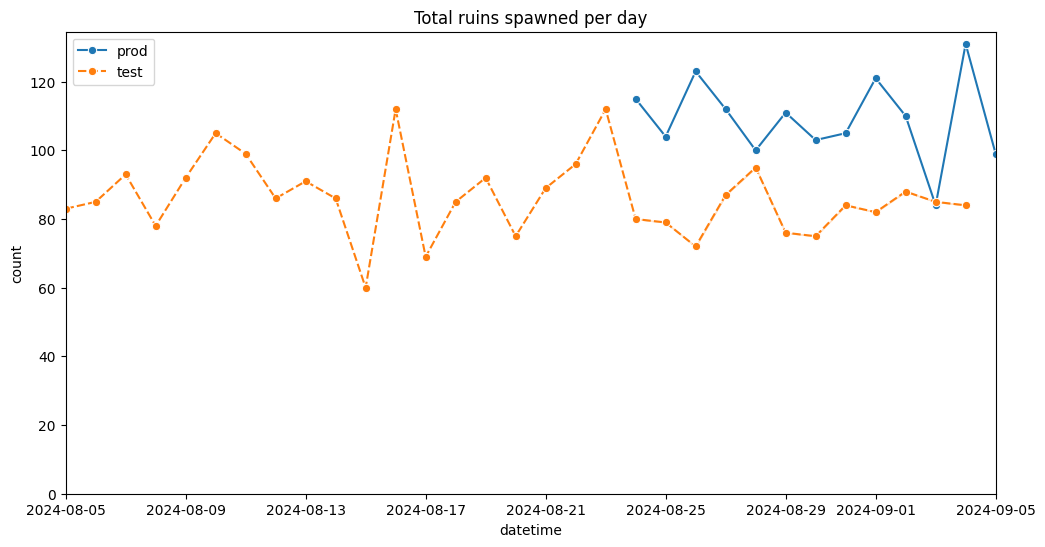

In [12]:
def ruins_daily_sum_data(prod, test):
    data = dict()
    data['prod'] = prod.groupby(['datetime'])['total'].sum()
    data['test'] = test.groupby(['datetime'])['total'].sum()
    return data

fig, ax = plt.subplots()
fig.set_size_inches(12, 6)

sns.lineplot(data=ruins_daily_sum_data(prod_dated_ruin_count, test_dated_ruin_count), marker='o')

ax.set(ylabel='count')
ax.set(title='Total ruins spawned per day')
plt.xlim(date(2024, 8, 5), date(2024, 9, 5))
ax.set_ylim(ymin=0)
plt.savefig('ruins_daily_sum.png')

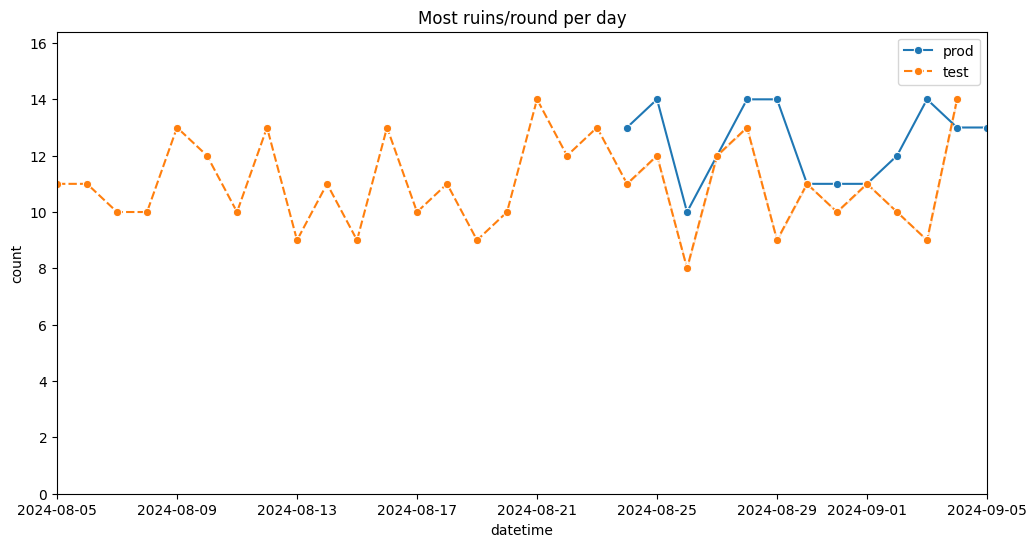

In [13]:
def ruins_daily_max_data(prod, test):
    data = dict()
    data['prod'] = prod.groupby(['datetime'])['total'].max()
    data['test'] = test.groupby(['datetime'])['total'].max()
    return data

fig, ax = plt.subplots()
fig.set_size_inches(12, 6)

sns.lineplot(data=ruins_daily_max_data(prod_dated_ruin_count, test_dated_ruin_count), marker='o')

ax.set(ylabel='count')
ax.set(title='Most ruins/round per day')
plt.xlim(date(2024, 8, 5), date(2024, 9, 5))
ax.set_ylim(ymin=0)
plt.savefig('ruins_daily_max.png')

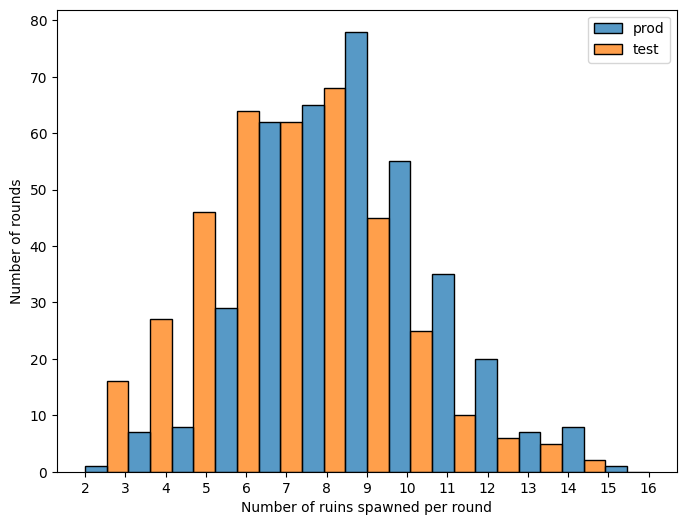

In [14]:
def get_histogram_data(test, prod):
    data = dict()
    data['prod'] = prod['total']
    data['test'] = test['total']
    return data
    
fig, ax = plt.subplots()
fig.set_size_inches(8, 6)

ax.locator_params(axis='x', integer=True)
ax.set_xlabel("Number of ruins spawned per round")
ax.set_ylabel("Number of rounds")
ax.yaxis.set_ticks(np.arange(0, 160, 10))
ax.xaxis.set_ticks(np.arange(0, 18, 1))
sns.histplot(data=get_histogram_data(test_dated_ruin_count, prod_dated_ruin_count), multiple='dodge', bins=13)

plt.savefig('ruin_spawn_count_histogram.png')

In [15]:
problem_ruins = [
    "abandoned_sec_shuttle.dmm",
    "asteroid1.dmm",
]
ruin_shortnames = [x.replace('.dmm', '') for x in problem_ruins]

In [16]:
test_total_ruin_count = get_total_ruin_count(raw_test_ruins)
prod_dated_ruin_count = get_total_ruin_count(raw_prod_ruins)
prod_dated_ruin_count['datetime'] = pd.to_datetime(prod_dated_ruin_count['datetime']).dt.date
test_total_ruin_count["range"] =  pd.cut(test_total_ruin_count.index.values, bins=summed_dates.val.values, right=True, include_lowest=True)
test_dated_ruin_count = from_range_to_date(test_total_ruin_count)

In [17]:
max_bin = max(prod_dated_ruin_count['total'].max(), test_dated_ruin_count['total'].max())
min_bin = min(prod_dated_ruin_count['total'].min(), test_dated_ruin_count['total'].min())

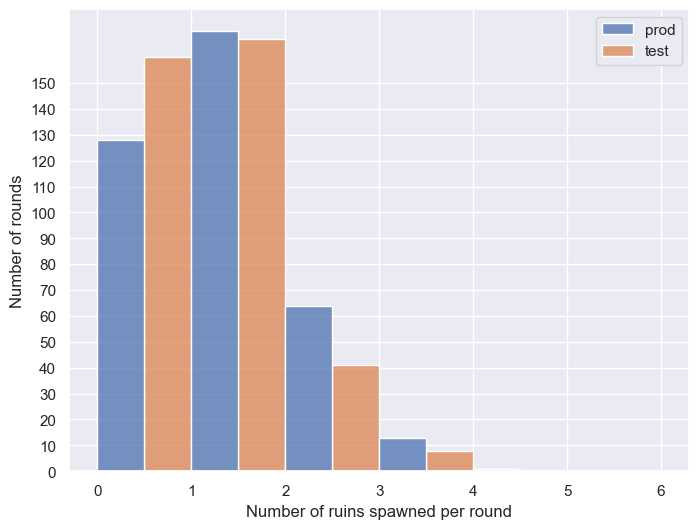

In [18]:
sns.set_theme()
fig, ax = plt.subplots()
fig.set_size_inches(8, 6)

ax.locator_params(axis='x', integer=True)
ax.set_xlabel("Number of ruins spawned per round")
ax.set_ylabel("Number of rounds")
ax.yaxis.set_ticks(np.arange(0, 160, 10))
sns.histplot(data=get_histogram_data(test_dated_ruin_count, prod_dated_ruin_count), multiple='dodge', bins=[0, 1, 2, 3, 4, 5, 6])

plt.savefig('ruin_spawn_count_histogram.png')

In [19]:
problem_ruins = [
    "ussp.dmm",
    "telecomns_returns.dmm",
]
ruin_shortnames = [x.replace('.dmm', '') for x in problem_ruins]

In [20]:
test_total_ruin_count = get_total_ruin_count(raw_test_ruins)
prod_dated_ruin_count = get_total_ruin_count(raw_prod_ruins)
prod_dated_ruin_count['datetime'] = pd.to_datetime(prod_dated_ruin_count['datetime']).dt.date
test_total_ruin_count["range"] =  pd.cut(test_total_ruin_count.index.values, bins=summed_dates.val.values, right=True, include_lowest=True)
test_dated_ruin_count = from_range_to_date(test_total_ruin_count)

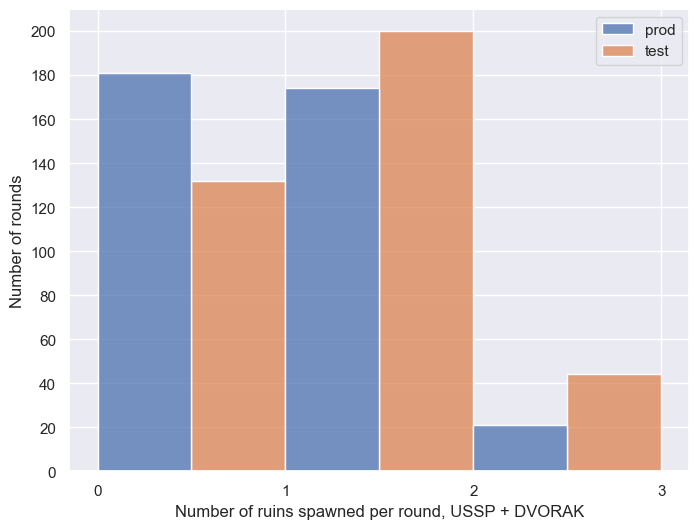

In [21]:
sns.set_theme()
fig, ax = plt.subplots()
fig.set_size_inches(8, 6)
ax.locator_params(axis='x', integer=True)
ax.set_xlabel("Number of ruins spawned per round, USSP + DVORAK")
ax.set_ylabel("Number of rounds")
ax.yaxis.set_ticks(np.arange(0, 250, 20))
sns.histplot(data=get_histogram_data(test_dated_ruin_count, prod_dated_ruin_count), multiple='dodge', bins=[0, 1, 2, 3])
plt.savefig('ruin_spawn_count_histogram_ussp_dvorak.png')

In [22]:
problem_ruins = {'abandoned_engi_sat.dmm',
 'abandoned_sec_shuttle.dmm',
 'abandonedtele.dmm',
 'abandonedzoo.dmm',
 'asteroid1.dmm',
 'asteroid2.dmm',
 'asteroid3.dmm',
 'asteroid4.dmm',
 'asteroid5.dmm',
 'blowntcommsat.dmm',
 'casino.dmm',
 'clownmime.dmm',
 'debris1.dmm',
 'debris2.dmm',
 'debris3.dmm',
 'deepstorage.dmm',
 'derelict1.dmm',
 'derelict2.dmm',
 'derelict3.dmm',
 'derelict4.dmm',
 'derelict5.dmm',
 'dj.dmm',
 'druglab.dmm',
 'emptyshell.dmm',
 'golemtarget.dmm',
 'intactemptyship.dmm',
 'listeningpost.dmm',
 'meatpackers.dmm',
 'mechtransport.dmm',
 'moonoutpost19.dmm',
 'oldstation.dmm',
 'onehalf.dmm',
 'rocky_motel.dmm',
 'spacebar.dmm',
 'syndicatedruglab.dmm',
 'syndie_space_base.dmm',
 'syndiecakesfactory.dmm',
 'syndiedepot.dmm',
 'telecomns_returns.dmm',
 'turretedoutpost.dmm',
 'ussp.dmm',
 'ussp_tele.dmm',
 'voyager.dmm',
 'way_home.dmm',
 'whiteship.dmm',
 'wizardcrash.dmm',
 'wreckedcargoship.dmm'}
ruin_shortnames = [x.replace('.dmm', '') for x in problem_ruins]

In [23]:
test_per_ruin_count = get_individual_ruin_counts(raw_test_ruins)

In [24]:
test_per_ruin_count

,rocky_motel,abandoned_sec_shuttle,ussp_tele,asteroid3,syndicatedruglab,turretedoutpost,derelict1,debris3,telecomns_returns,intactemptyship,...,wreckedcargoship,asteroid4,abandoned_engi_sat,syndiedepot,whiteship,syndiecakesfactory,debris2,moonoutpost19,casino,meatpackers
0,0,1,0,0,0,1,0,1,0,1,...,0,0,0,1,1,1,0,0,0,1
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,1,1,0,0,0,0
2,1,1,1,0,1,0,0,1,0,2,...,0,4,0,1,1,0,1,1,0,0
3,0,1,0,1,0,0,0,1,1,0,...,0,1,0,1,1,0,0,0,0,0
4,0,0,1,0,0,0,0,0,1,1,...,0,1,1,1,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
371,0,1,0,0,0,0,0,0,0,0,...,0,0,1,1,1,1,0,0,0,0
372,0,1,0,0,1,0,0,1,1,0,...,0,1,0,1,1,0,0,0,0,0
373,0,0,0,0,1,0,0,0,0,0,...,0,0,0,1,1,0,0,0,0,0
374,0,1,0,0,0,0,0,0,0,0,...,1,1,0,1,1,1,0,1,0,0


In [25]:
prod_per_ruin_count = get_individual_ruin_counts(raw_prod_ruins)

In [26]:
prod_per_ruin_count

,datetime,rocky_motel,abandoned_sec_shuttle,ussp_tele,asteroid3,syndicatedruglab,turretedoutpost,derelict1,debris3,telecomns_returns,...,wreckedcargoship,asteroid4,abandoned_engi_sat,syndiedepot,whiteship,syndiecakesfactory,debris2,moonoutpost19,casino,meatpackers
0,2024-08-24 01:50:02,0,0,2,0,0,0,1,0,1,...,0,1,0,1,1,1,0,0,1,0
1,2024-08-24 04:08:48,0,0,0,1,0,1,0,0,1,...,0,1,0,1,1,1,0,0,1,1
2,2024-08-24 06:27:28,0,0,0,0,0,0,0,1,0,...,1,0,0,1,1,0,0,0,0,1
3,2024-08-24 06:43:38,1,1,2,0,0,0,1,0,0,...,1,0,0,1,1,0,0,1,0,1
4,2024-08-24 09:06:40,0,1,0,0,1,0,1,0,0,...,0,0,0,1,1,1,0,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
371,2024-09-23 15:54:43,0,1,0,0,0,0,0,0,1,...,0,0,0,1,1,0,0,1,0,0
372,2024-09-23 18:12:41,1,0,1,1,1,1,3,0,0,...,1,0,1,1,1,1,0,0,0,0
373,2024-09-23 20:37:23,0,1,0,0,0,0,2,0,1,...,0,1,0,1,1,1,0,1,0,1
374,2024-09-23 22:31:21,0,1,0,0,1,1,1,0,0,...,0,0,0,1,1,0,0,0,1,0


In [27]:
prod_per_ruin_count['datetime'] = pd.to_datetime(prod_per_ruin_count['datetime']).dt.date
test_per_ruin_count["range"] =  pd.cut(test_per_ruin_count.index.values, bins=summed_dates.val.values, right=True, include_lowest=True)
test_per_ruin_count = from_range_to_date(test_per_ruin_count)

In [28]:
test_per_ruin_count

,datetime,rocky_motel,abandoned_sec_shuttle,ussp_tele,asteroid3,syndicatedruglab,turretedoutpost,derelict1,debris3,telecomns_returns,...,wreckedcargoship,asteroid4,abandoned_engi_sat,syndiedepot,whiteship,syndiecakesfactory,debris2,moonoutpost19,casino,meatpackers
0,2024-08-05,0,1,0,0,0,1,0,1,0,...,0,0,0,1,1,1,0,0,0,1
1,2024-08-05,0,0,0,0,0,0,0,0,0,...,0,0,0,1,1,1,0,0,0,0
2,2024-08-05,1,1,1,0,1,0,0,1,0,...,0,4,0,1,1,0,1,1,0,0
3,2024-08-05,0,1,0,1,0,0,0,1,1,...,0,1,0,1,1,0,0,0,0,0
4,2024-08-05,0,0,1,0,0,0,0,0,1,...,0,1,1,1,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
371,2024-09-04,0,1,0,0,0,0,0,0,0,...,0,0,1,1,1,1,0,0,0,0
372,2024-09-04,0,1,0,0,1,0,0,1,1,...,0,1,0,1,1,0,0,0,0,0
373,2024-09-04,0,0,0,0,1,0,0,0,0,...,0,0,0,1,1,0,0,0,0,0
374,2024-09-04,0,1,0,0,0,0,0,0,0,...,1,1,0,1,1,1,0,1,0,0


In [29]:
combined = pd.DataFrame({
    'prod': prod_per_ruin_count.drop(['datetime'], axis=1).sum(),
    'test': test_per_ruin_count.drop(['datetime'], axis=1).sum(),
})

In [30]:
print(combined.to_csv())

,prod,test
rocky_motel,168,83
abandoned_sec_shuttle,143,173
ussp_tele,165,100
asteroid3,186,91
syndicatedruglab,142,98
turretedoutpost,163,101
derelict1,176,93
debris3,161,84
telecomns_returns,113,146
intactemptyship,192,106
debris1,174,98
druglab,176,85
ussp,103,142
voyager,138,86
onehalf,189,101
wizardcrash,135,188
derelict4,179,100
blowntcommsat,137,164
derelict3,146,157
abandonedtele,189,117
asteroid5,144,97
deepstorage,129,167
listeningpost,180,77
dj,157,212
way_home,165,89
spacebar,376,376
golemtarget,376,376
asteroid1,198,100
derelict5,165,89
clownmime,207,108
emptyshell,186,102
mechtransport,140,87
oldstation,376,376
derelict2,188,92
syndie_space_base,376,376
abandonedzoo,182,90
asteroid2,152,96
wreckedcargoship,145,97
asteroid4,176,121
abandoned_engi_sat,130,76
syndiedepot,376,376
whiteship,376,376
syndiecakesfactory,124,162
debris2,187,110
moonoutpost19,130,175
casino,132,69
meatpackers,145,66



In [270]:
pd.merge([, test_per_ruin_count.drop(['datetime'], axis=1).sum()])

TypeError: merge() missing 1 required positional argument: 'right'

In [265]:
test_per_ruin_count.drop(['datetime'], axis=1).sum()

abandoned_engi_sat       163
rocky_motel              149
intactemptyship          225
listeningpost            198
abandonedzoo             202
blowntcommsat            138
derelict3                162
whiteship                376
asteroid1                229
syndicatedruglab         137
asteroid3                238
debris1                  229
turretedoutpost          189
meatpackers              139
syndie_space_base        376
golemtarget              376
asteroid5                201
dj                       167
debris2                  200
druglab                  217
moonoutpost19            137
ussp                     109
oldstation               376
syndiedepot              376
wizardcrash              177
wreckedcargoship         131
way_home                 220
emptyshell               232
spacebar                 376
derelict1                191
asteroid2                204
derelict5                175
abandoned_sec_shuttle    147
voyager                  169
telecomns_retu

In [261]:
prod_per_ruin_count['asteroid1'].sum()

198

In [262]:
test_per_ruin_count['asteroid1'].sum()

229

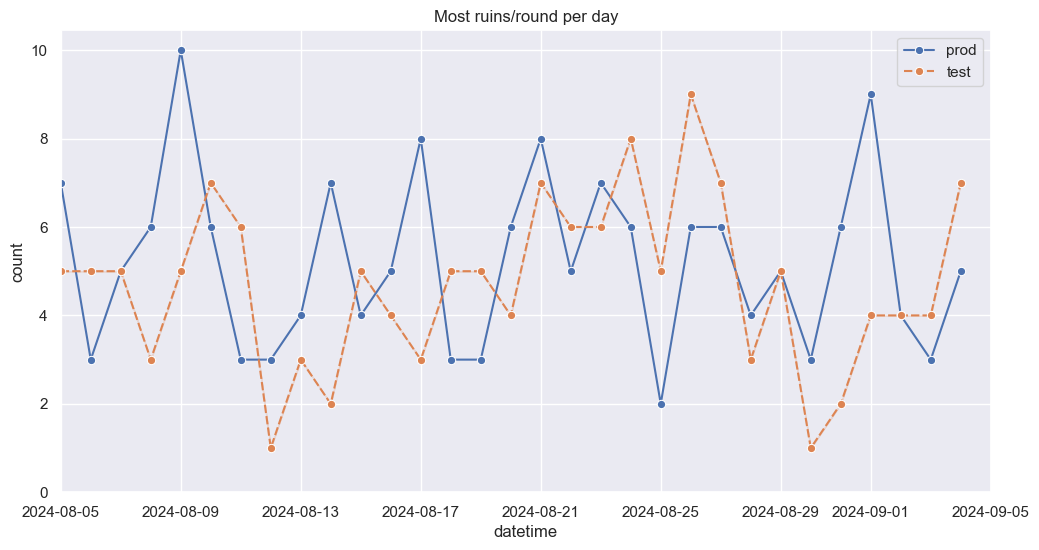

In [234]:
def ruins_daily_max_data(prod, test):
    data = dict()
    data['prod'] = prod.groupby(['datetime'])['abandoned_sec_shuttle'].sum()
    data['test'] = test.groupby(['datetime'])['abandoned_sec_shuttle'].sum()
    return data

fig, ax = plt.subplots()
fig.set_size_inches(12, 6)

sns.lineplot(data=ruins_daily_max_data(prod_per_ruin_count, test_per_ruin_count), marker='o')

ax.set(ylabel='count')
ax.set(title='Most ruins/round per day')
plt.xlim(date(2024, 8, 5), date(2024, 9, 5))
ax.set_ylim(ymin=0)
plt.savefig('ruins_daily_max_.png')